<a href="https://colab.research.google.com/github/ralhawas2-cloud/GPA-calculator-java/blob/main/IT315_PROJECTIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 import pandas as pd
 import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
class DataLoader:

    def __init__(self):
        # هنا نجهز المتغيرات الأساسية ونحمل الداتا الجاهزة
        self.data = None

        # تحميل dataset الخاص بالـ Iris من sklearn
        self.iris = load_iris()

    def load_data(self):
        # نحول البيانات إلى جدول (DataFrame) عشان يصير التعامل معها أسهل
        self.data = pd.DataFrame(
            self.iris.data,
            columns=self.iris.feature_names
        )

        # نضيف العمود الخاص بالتصنيفات (0,1,2)
        self.data['target'] = self.iris.target

        # نحول الأرقام إلى أسماء الأنواع الحقيقية للزهور
        self.data['species'] = [
            self.iris.target_names[i] for i in self.iris.target
        ]

        # بس تأكيد بسيط إن البيانات تحملت بدون مشاكل
        print("✅ تم تحميل البيانات بنجاح!")

        # نرجع الداتا عشان تستخدمها باقي الكلاسات
        return self.data

    def get_summary(self):
        # نتأكد أول إن البيانات محملة قبل ما نطلع الإحصائيات
        if self.data is None:
            print("⚠️  لم يتم تحميل البيانات بنجاح")
            return None

        # نعرض ملخص سريع عن البيانات (متوسط، أقل، أعلى قيم...)
        return self.data.describe()

In [4]:

class DataVisualizer:

    def __init__(self, data):
        # هنا نستقبل البيانات الجاهزة من كلاس DataLoader
        self.data = data

    def show_basic_info(self):
        # نعرض أول 5 صفوف من البيانات عشان نشوف شكلها العام
        print("📊 أول 5 صفوف من البيانات:")
        print(self.data.head())

    def plot_histograms(self):
        # نرسم Histogram لكل الأعمدة الرقمية لمعرفة توزيع القيم
        self.data.hist(figsize=(10, 8))

        # نضيف عنوان عام للرسم
        plt.suptitle("Histogram of Iris Features")

        # عرض الرسومات
        plt.show()

    def scatter_plot(self):
        # نرسم Scatter Plot بين طول وعرض البتلة (Petal)
        plt.figure(figsize=(8, 6))

        # نكرر على كل نوع من الزهور عشان نعطي كل نوع لون مختلف
        for species in self.data['species'].unique():

            # نفلتر البيانات حسب النوع الحالي
            subset = self.data[self.data['species'] == species]

            # نرسم النقاط لكل نوع
            plt.scatter(
                subset['petal length (cm)'],
                subset['petal width (cm)'],
                label=species
            )

        # تسمية المحاور
        plt.xlabel("Petal Length")
        plt.ylabel("Petal Width")

        # عنوان الرسم
        plt.title("Petal Length vs Petal Width")

        # عرض الليجند (أسماء الأنواع)
        plt.legend()

        # عرض الرسم
        plt.show()

    def box_plot(self):
        # رسم Boxplot لجميع الخصائص لمعرفة القيم المتطرفة وتوزيع البيانات
        self.data.boxplot(figsize=(10, 6))

        # عنوان الرسم
        plt.title("Boxplot of Features")

        # عرض الرسم
        plt.show()

In [5]:
class IrisModel:
    def __init__(self, data):
        """
        الـ Constructor لتجهيز البيانات وتحديد الـ Attributes للموديل
        """
        # تحديد الخصائص (X) والهدف (y) تبعا لبيانات المشروع (species)
        self.X = data.drop('species', axis=1)
        self.y = data['species']
        # استخدام Instance من موديل Decision Tree كما هو مطلوب
        self.model = DecisionTreeClassifier(random_state=42)

    def split_data(self):
        """
        ميثود الخطوة 3: تقسيم البيانات بنسبة 80% للتدريب و 20% للاختبار
        """
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )
        print("✅ تم تقسيم البيانات بنجاح ")

    def train_model(self):
        """
        ميثود الخطوة 4: عمل Fitting وتدريب للموديل
        """
        self.model.fit(self.X_train, self.y_train)
        print("✅ تم تدريب الموديل بنجاح ")

    def evaluate_model(self):
        """
        ميثود الخطوة 5: حساب الـ Accuracy لقياس أداء الموديل
        """
        predictions = self.model.predict(self.X_test)
        accuracy = accuracy_score(self.y_test, predictions)
        print("-" * 35)
        print(f"📊 دقة الموديل النهائية هي: {accuracy * 100:.2f}%")
        print("-" * 35)

In [6]:
class IrisApp:
    def __init__(self):
        # نسوي object من DataLoader عشان نستخدمه في تحميل البيانات
        self.loader = DataLoader()

    def run(self):
        # نحمل البيانات من الكلاس الأول
        data = self.loader.load_data()

        # نسوي عرض للبيانات + الرسومات
        visualizer = DataVisualizer(data)
        visualizer.show_basic_info()   # يعرض أول 5 صفوف
        visualizer.plot_histograms()   # يرسم التوزيع
        visualizer.scatter_plot()      # يرسم العلاقة بين المتغيرات
        visualizer.box_plot()          # يوضح القيم الشاذة

        # نسوي موديل ونبدأ التدريب
        model = IrisModel(data)
        model.split_data()     # نقسم البيانات تدريب واختبار
        model.train_model()    # ندرب الموديل
        model.evaluate_model() # نقيس الدقة

        # نرجع الموديل عشان نستخدمه في البونس
        return model


✅ تم تحميل البيانات بنجاح!
📊 أول 5 صفوف من البيانات:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


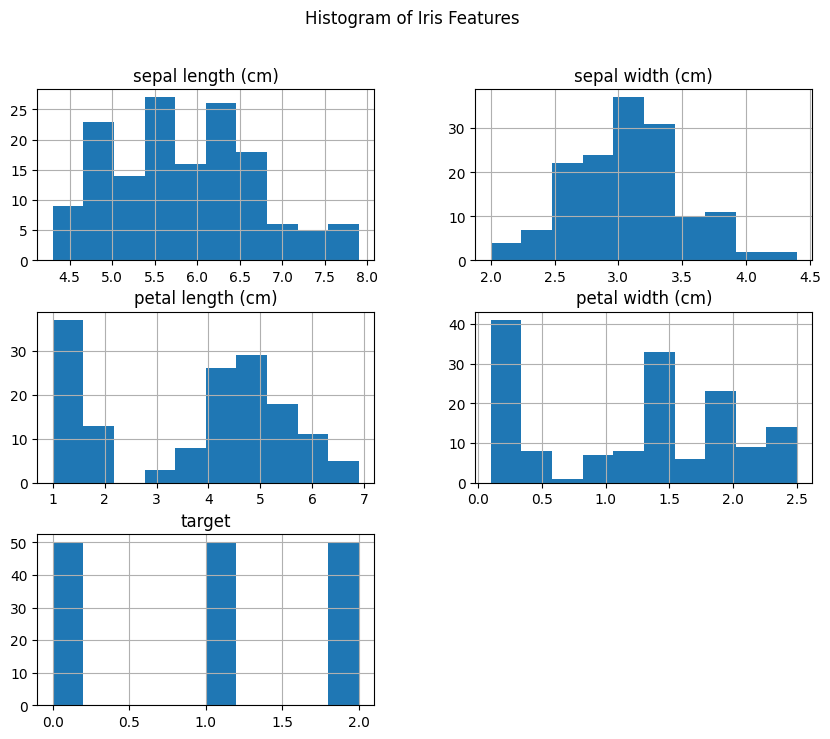

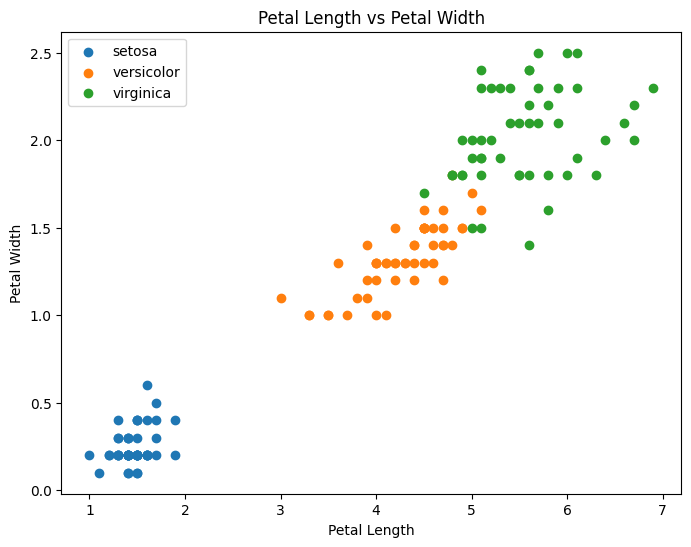

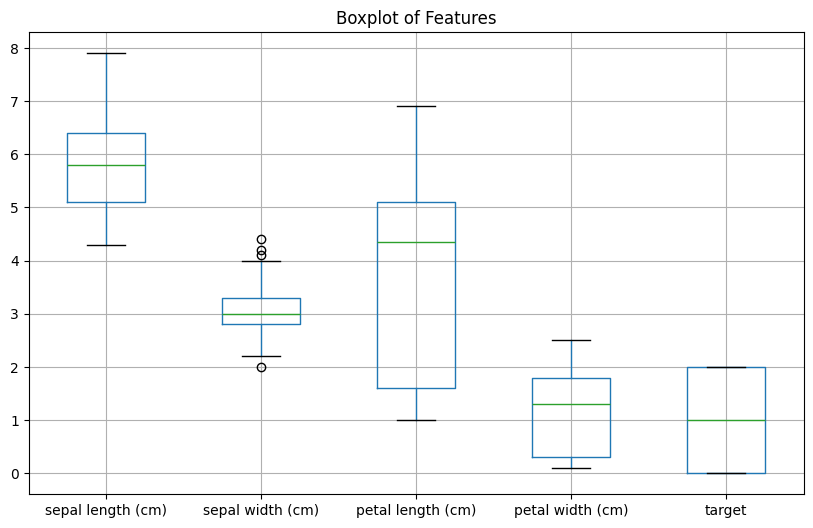

✅ تم تقسيم البيانات بنجاح 
✅ تم تدريب الموديل بنجاح 
-----------------------------------
📊 دقة الموديل النهائية هي: 100.00%
-----------------------------------


In [7]:
app = IrisApp()
model = app.run()


In [8]:
import tkinter as tk

class IrisGUI:
    def __init__(self, model):
        # نخزن الموديل المدرب عشان نستخدمه في التوقع
        self.model = model

        # نسوي نافذة التطبيق
        self.window = tk.Tk()
        self.window.title("Iris Predictor")

        # حقول إدخال البيانات (قيم الزهرة)

        tk.Label(self.window, text="Sepal Length").pack()
        self.sl = tk.Entry(self.window)
        self.sl.pack()

        tk.Label(self.window, text="Sepal Width").pack()
        self.sw = tk.Entry(self.window)
        self.sw.pack()

        tk.Label(self.window, text="Petal Length").pack()
        self.pl = tk.Entry(self.window)
        self.pl.pack()

        tk.Label(self.window, text="Petal Width").pack()
        self.pw = tk.Entry(self.window)
        self.pw.pack()

        # زر التوقع
        tk.Button(self.window, text="Predict", command=self.predict).pack()

        # مكان عرض النتيجة
        self.result = tk.Label(self.window, text="")
        self.result.pack()

    def predict(self):
        # ناخذ القيم اللي كتبها المستخدم
        sample = [
            float(self.sl.get()),
            float(self.sw.get()),
            float(self.pl.get()),
            float(self.pw.get())
        ]

        # نسوي توقع باستخدام الموديل
        pred = self.model.predict(sample)

        # أسماء الأنواع
        classes = ['Setosa', 'Versicolor', 'Virginica']

        # نعرض النتيجة للمستخدم
        self.result.config(text=f"التوقع: {classes[pred]}")

    def run(self):
        # نشغل الواجهة
        self.window.mainloop()

In [9]:
gui = IrisGUI(model.model)
gui.run()

TclError: no display name and no $DISPLAY environment variable